# TODO:
- [x] load data
- [x] create regression predictions and curves
- [x] calculate covariance
- [x] combine into markowitz model
- [x] use wsm ecm with quadratic solver to create pareto from
- [x] compare efficiency of those methods for finding unique pareto solutions (visualize fronts)
- [ ] select best prediction 

### Dependencies


In [105]:
import numpy as np
import glob
import sklearn
import matplotlib.pyplot as plt
import cvxopt
cvxopt.solvers.options['show_progress'] = False
import ipywidgets as widgets
from ipywidgets import interact


### Load Data

Results in `stocks` dictionary

In [106]:
def load_stock_data(filename):
    with open(filename, "r") as file:
        name : str
        n : int
        datapoints = []
        for i, line in enumerate(file):
            line = line.strip()
            if i == 0:
                name = line
            elif i == 1:
                n = int(line)
            else:
                _, point = line.split(" ")
                point = float(point)
                datapoints.append(point)
        assert(len(datapoints) == n)
        return name, np.array(datapoints)

In [107]:
stocks = {}
for stock_filename in glob.glob("bundle1/*.txt"):
    name, datapoints = load_stock_data(stock_filename)
    stocks[name] = datapoints
print(f"Loaded {len(stocks)} stocks")

Loaded 20 stocks


### Prediction functions and curves
Results in `stocks_predicted_ratios` dictionary

In [108]:
def linear_regression_prediction(datapoints, n_past_samples):
    x = np.arange(n_past_samples,len(datapoints)).reshape(-1, 1)
    print(x)
    reg = sklearn.linear_model.LinearRegression().fit(x, datapoints[n_past_samples:])
    err = np.std(datapoints[n_past_samples:] - reg.predict(x))
    px = np.arange(len(datapoints), len(datapoints) + 100).reshape(-1, 1) # go to next T
    return np.clip(reg.predict(px), a_min=err, a_max=np.inf), err

def create_harmonic_elements(x, harmonic_order, period_len):
    intercept = np.ones_like(x)
    components = [intercept, x]
    for order in range(1, harmonic_order+1):
        zx = 2 * np.pi * order * x / period_len
        comp = np.sin(zx) + np.cos(zx)
        components.append(comp)
    components = np.column_stack(components)
    return components
    

def harmonic_regression_prediction(datapoints, harmonic_order, period_len):
    x = create_harmonic_elements(np.arange(len(datapoints)), harmonic_order, period_len)
    reg = sklearn.linear_model.BayesianRidge().fit(x, np.log(datapoints))
    err = np.std(datapoints - np.exp(reg.predict(x)))

    px = create_harmonic_elements(np.arange(len(datapoints), len(datapoints) + 100), harmonic_order, period_len) # go to next T
    return np.exp(reg.predict(px)), err




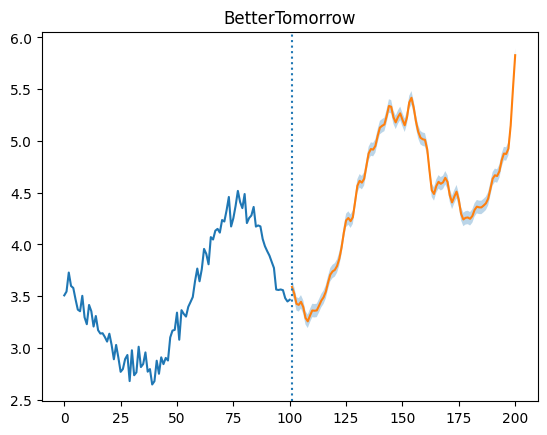

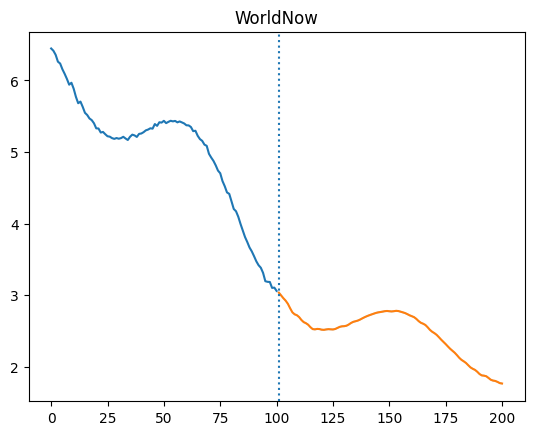

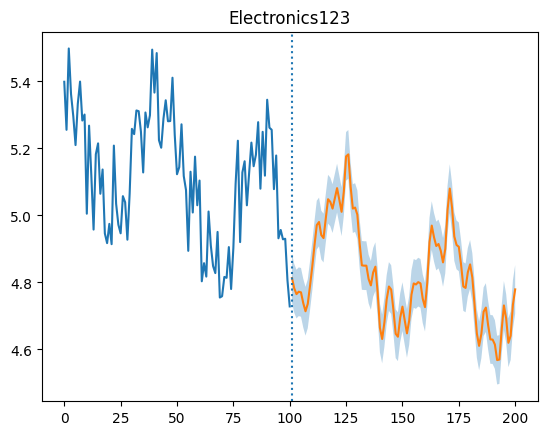

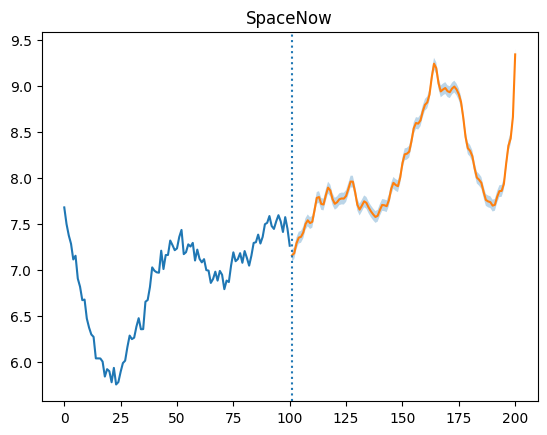

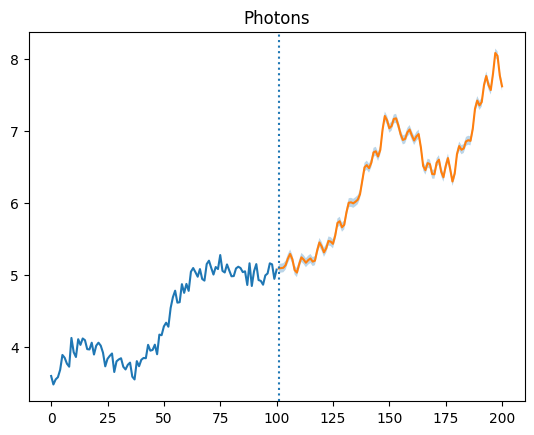

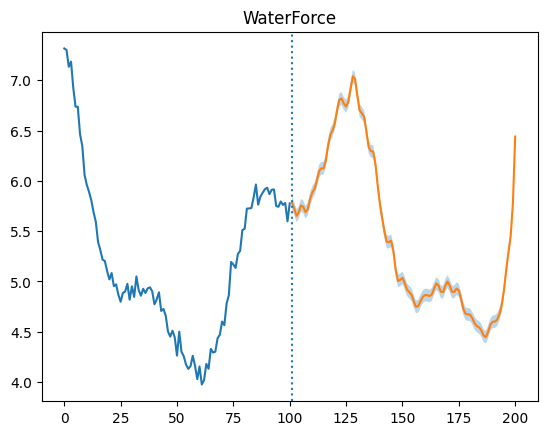

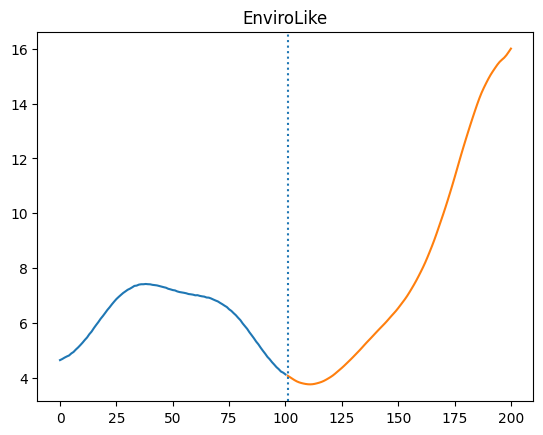

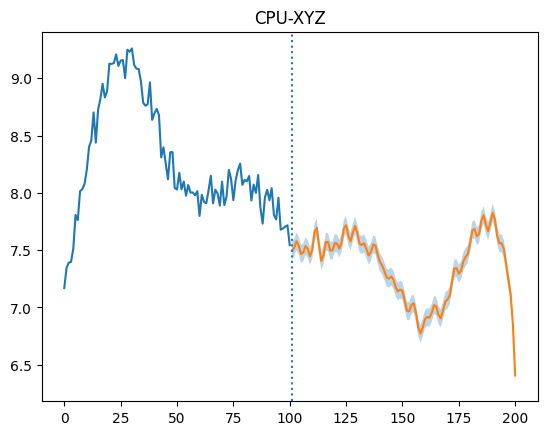

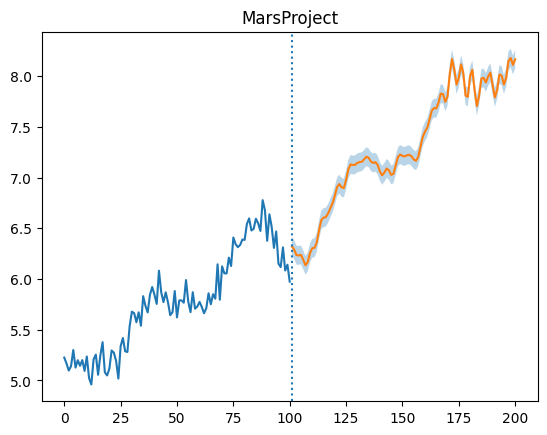

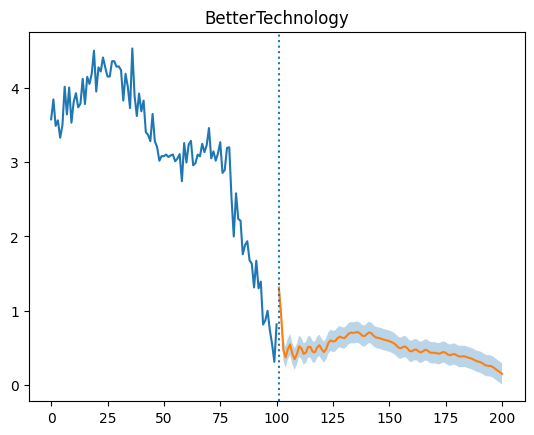

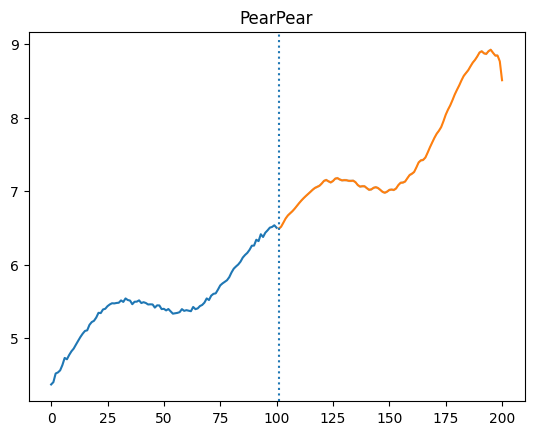

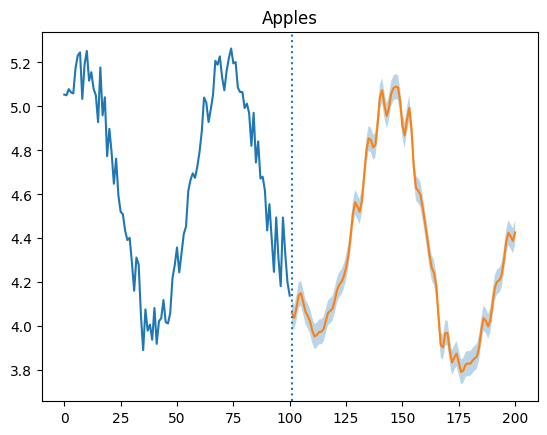

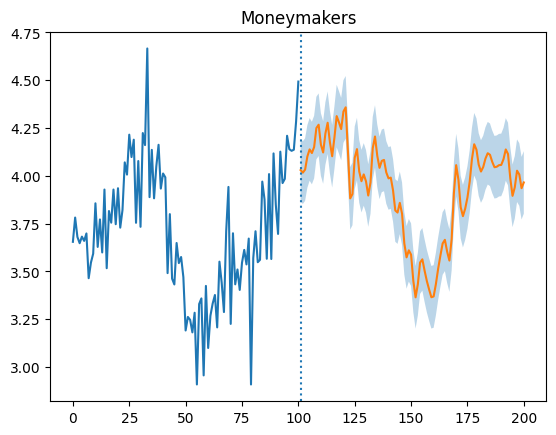

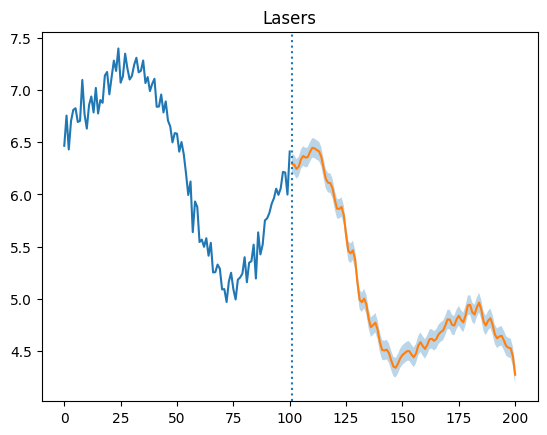

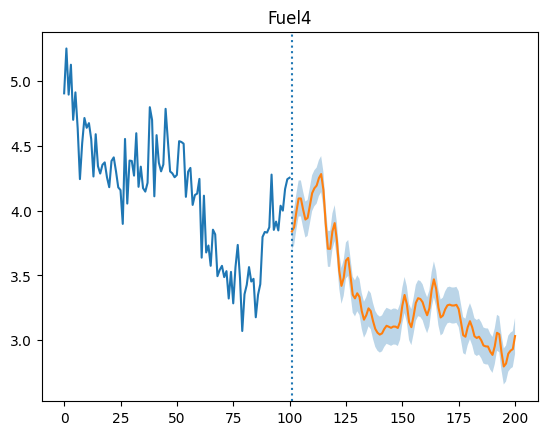

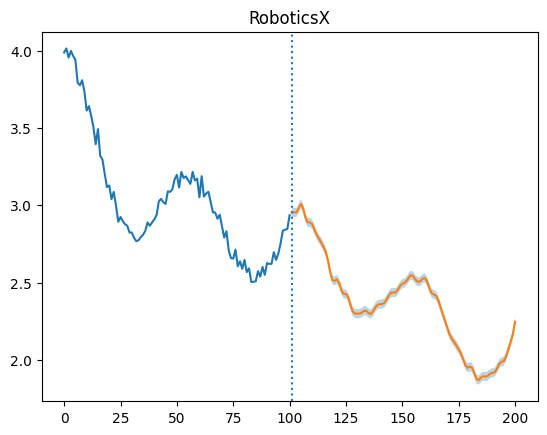

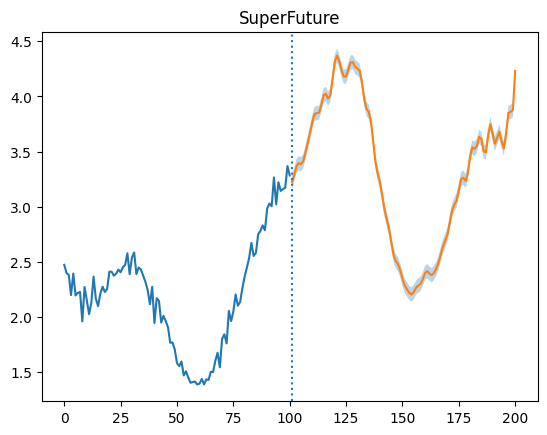

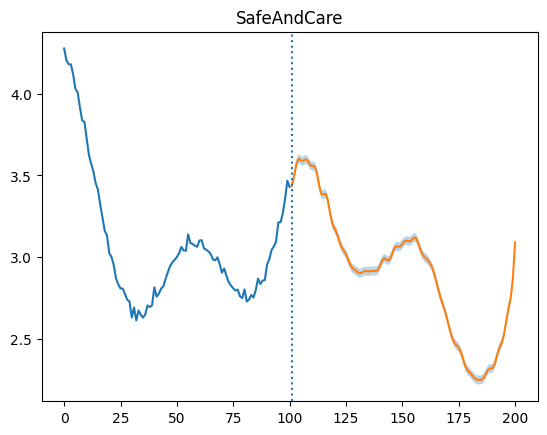

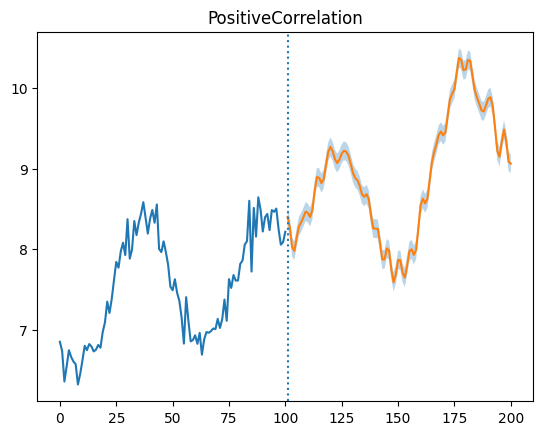

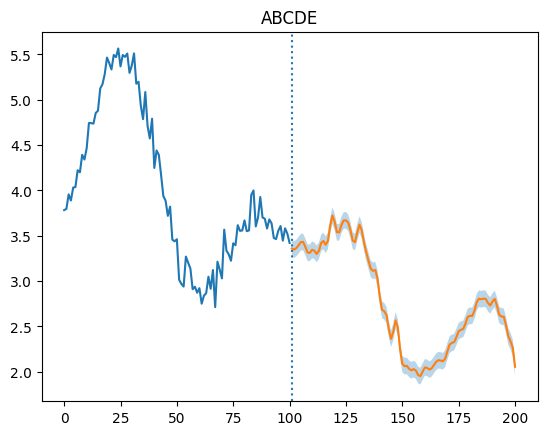

In [109]:
stocks_predicted_ratios = {} # predictions for last day only
harmonic_order=50
period_len=201
for stock_name, stock_datapoints in stocks.items():
    predictions, err = harmonic_regression_prediction(stock_datapoints,harmonic_order, period_len)
    stocks_predicted_ratios[stock_name] = predictions[-1] / stock_datapoints[-1]
    x = np.arange(len(stock_datapoints))
    plt.plot(x, stock_datapoints)
    px = np.arange(len(stock_datapoints), len(stock_datapoints) + 100)
    plt.plot(px, predictions)
    plt.axvline(len(stock_datapoints), linestyle="dotted")
    plt.fill_between(px, predictions - err, predictions + err, alpha=0.3)
    plt.title(stock_name)
    plt.show()


In [110]:
print(stocks_predicted_ratios)

{'BetterTomorrow': np.float64(1.6820587623535688), 'WorldNow': np.float64(0.577808092492954), 'Electronics123': np.float64(1.0107460654935336), 'SpaceNow': np.float64(1.2866414331090217), 'Photons': np.float64(1.5018283496361389), 'WaterForce': np.float64(1.1149051862402135), 'EnviroLike': np.float64(3.874262174101115), 'CPU-XYZ': np.float64(0.8491994516200962), 'MarsProject': np.float64(1.3670852968535636), 'BetterTechnology': np.float64(0.1872236507162988), 'PearPear': np.float64(1.308687732476425), 'Apples': np.float64(1.0694665937301264), 'Moneymakers': np.float64(0.8826142152450742), 'Lasers': np.float64(0.6666599183790536), 'Fuel4': np.float64(0.7126391342871703), 'RoboticsX': np.float64(0.7648942445830987), 'SuperFuture': np.float64(1.2882140057790732), 'SafeAndCare': np.float64(0.9009255325296124), 'PositiveCorrelation': np.float64(1.1029150704640949), 'ABCDE': np.float64(0.6007223118322206)}


### Covariance

Results in `stocks_covariance` matrix and `stocks_expected_return` vector

In [111]:
m = []
stocks_expected_return = []
for stock in stocks:
    m.append(stocks[stock])
    stocks_expected_return.append(stocks_predicted_ratios[stock])
m = np.array(m)
stocks_covariance = np.cov(m)
stocks_expected_return = np.array(stocks_expected_return) - 1

### Solve QP with Weighted Sum Method

In [112]:
def evaluate_solution(weights, expected_return, covariance_matrix):
    return np.sum(weights * (expected_return)), weights.T @ covariance_matrix @ weights

def wsm_solve(risk_weight, expected_return, covariance_matrix, normalize = True):
    n_factor_risk = 1.0
    n_factor_return = 1.0
    if normalize:
        wreturn = wsm_solve(0.0, expected_return, covariance_matrix, normalize=False)
        wrisk = wsm_solve(1.0, expected_return, covariance_matrix, normalize=False)
        max_return, max_risk = evaluate_solution(wreturn, expected_return, covariance_matrix)
        min_return, min_risk = evaluate_solution(wrisk, expected_return, covariance_matrix)
        n_factor_return = 1 / (max_return - min_return)
        n_factor_risk = 1 / (max_risk - min_risk)
    n = len(expected_return)
    Q = cvxopt.matrix(2 * risk_weight * n_factor_risk * covariance_matrix) # we have to flip for correct column layout I think
    c = cvxopt.matrix((1 - risk_weight) * expected_return * -1 * n_factor_return)
    b = cvxopt.matrix(1.0)
    A = cvxopt.matrix(np.ones(shape=(1,n)))

    G = cvxopt.matrix(-np.eye(n))
    h = cvxopt.matrix(np.zeros(n))

    sol = cvxopt.solvers.qp(Q, c, G, h, A, b)
    weights = np.array(sol['x']).flatten()
    return weights



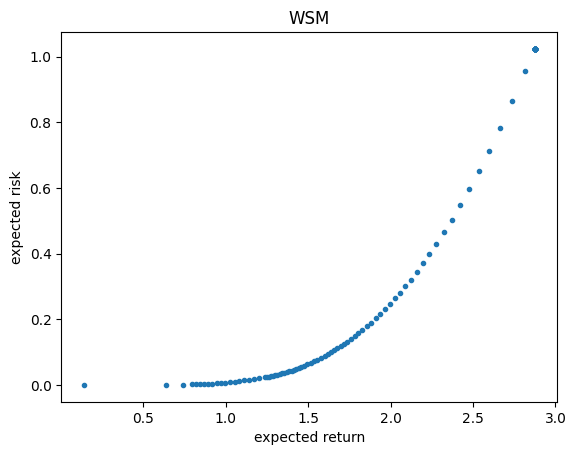

(np.float64(2.8742619121223347), np.float64(1.023134374557663))

In [113]:
n_samples = 100
wsm_x_returns = []
wsm_y_risks = []
wsm_solutions = []
for i in range(n_samples + 1):
    wcm_weight = 1 / n_samples * i
    w = wsm_solve(wcm_weight, stocks_expected_return, stocks_covariance)
    ereturn, risk = evaluate_solution(w, stocks_expected_return, stocks_covariance)
    wsm_x_returns.append(ereturn)
    wsm_y_risks.append(risk)
    wsm_solutions.append(w)
wsm_x_returns = np.array(wsm_x_returns)

plt.scatter(wsm_x_returns, wsm_y_risks, marker=".")
plt.xlabel("expected return")
plt.ylabel("expected risk")
plt.title("WSM")
plt.show()

evaluate_solution(wsm_solutions[0], stocks_expected_return, stocks_covariance)

### epsilon constrained method

In [114]:
def ecm_solve(epsilon, expected_return, covariance_matrix):
    n = len(expected_return)
    Q = cvxopt.matrix(2 * covariance_matrix) # we have to flip for correct column layout I think
    c = cvxopt.matrix(np.zeros(n))
    b = cvxopt.matrix(1.0)
    A = cvxopt.matrix(np.ones(shape=(1,n)))

    G = cvxopt.matrix(np.vstack((-expected_return,-np.eye(n))))
    h = np.zeros(n+1)
    h[0] = -epsilon
    h = cvxopt.matrix(h)

    sol = cvxopt.solvers.qp(Q, c, G, h, A, b)
    weights = np.array(sol['x']).flatten()
    return weights



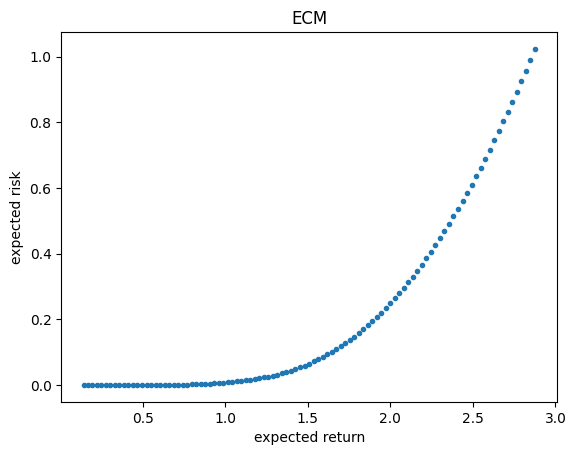

In [115]:
threshold_step = (np.max(wsm_x_returns)-np.min(wsm_x_returns))/n_samples
ecm_x_returns = []
ecm_y_risks = []
ecm_solutions = []
for i in range(n_samples + 1):
    t = i * threshold_step + np.min(wsm_x_returns)
    w = ecm_solve(t, stocks_expected_return, stocks_covariance)
    ereturn, risk = evaluate_solution(w, stocks_expected_return, stocks_covariance)
    ecm_x_returns.append(ereturn)
    ecm_y_risks.append(risk)
    ecm_solutions.append(w)
plt.scatter(ecm_x_returns, ecm_y_risks, marker=".")
plt.xlabel("expected return")
plt.ylabel("expected risk")
plt.title("ECM")
plt.show()


Expected return: 0.14, expected risk: 0.143240


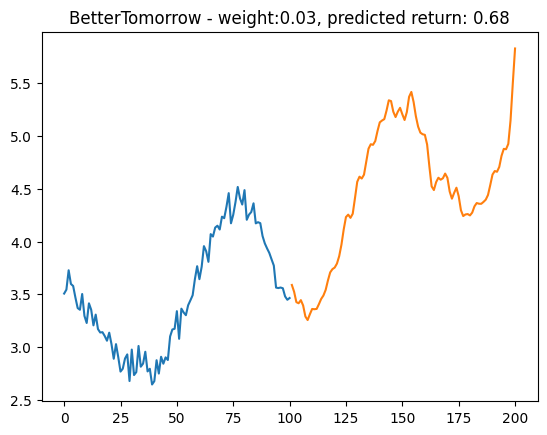

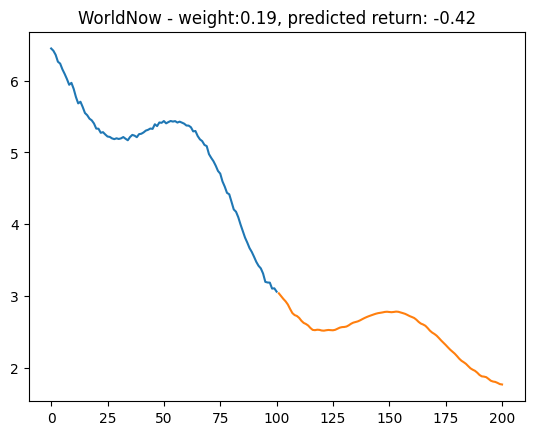

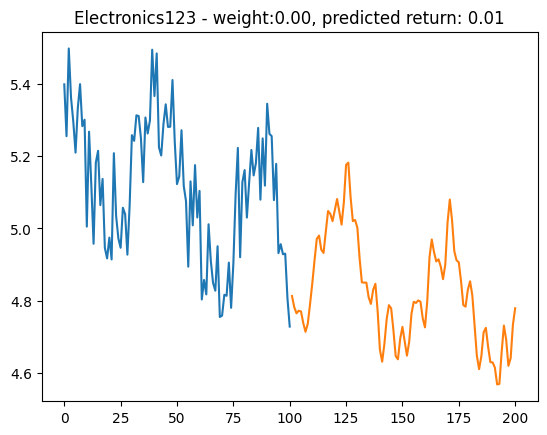

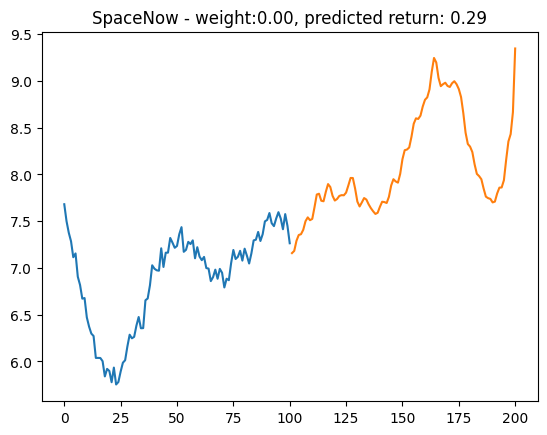

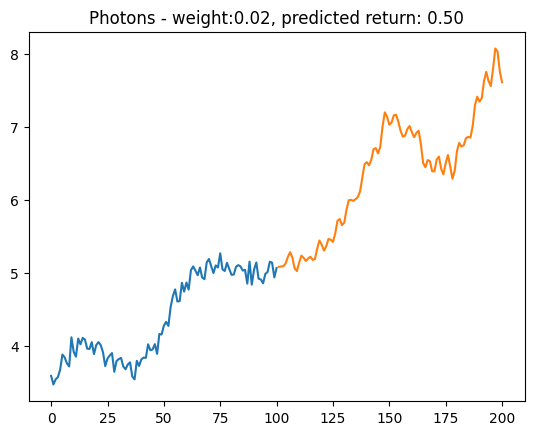

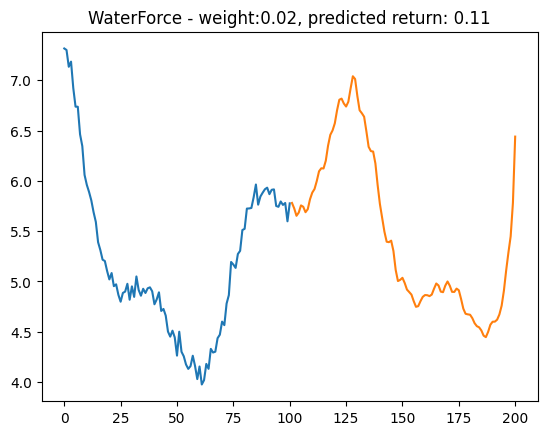

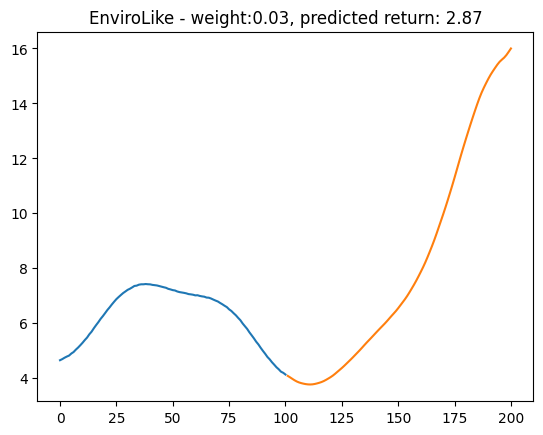

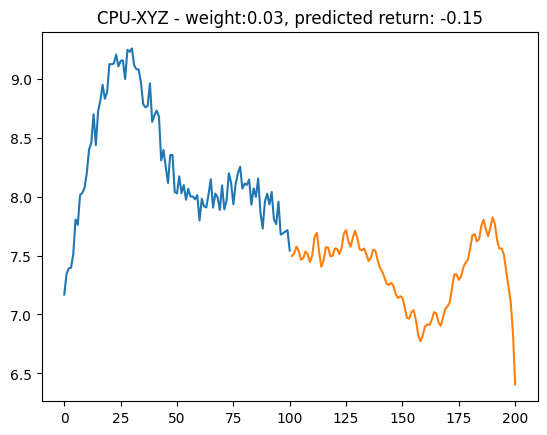

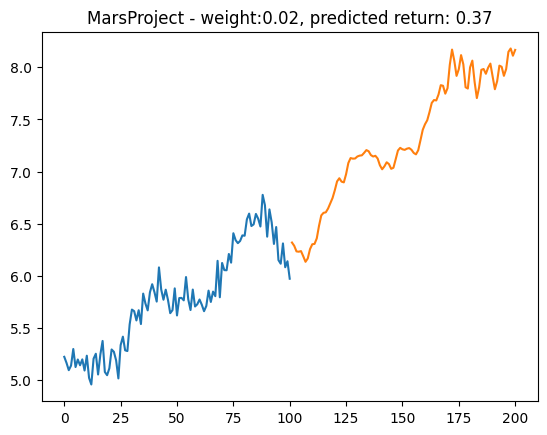

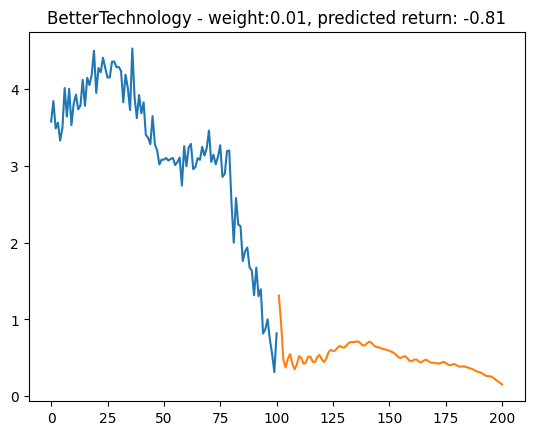

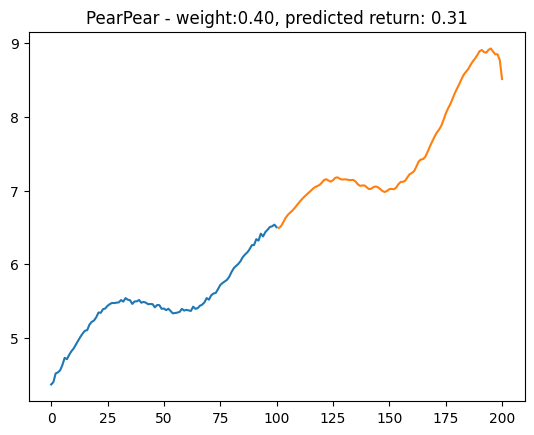

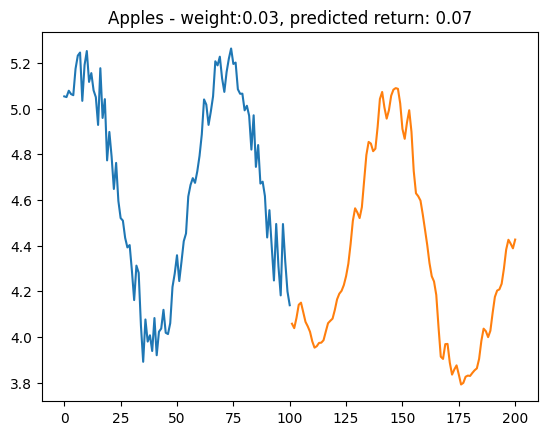

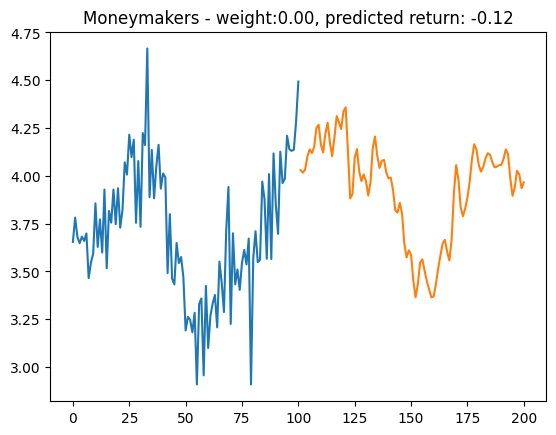

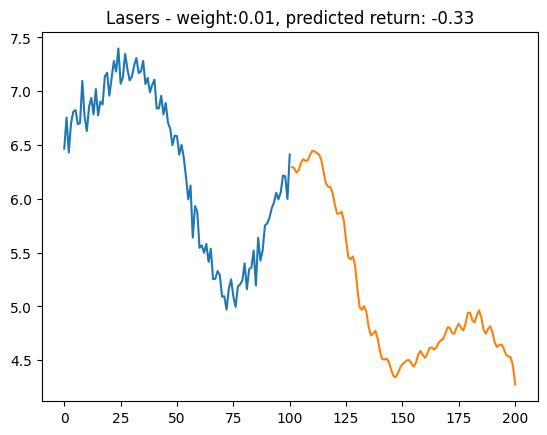

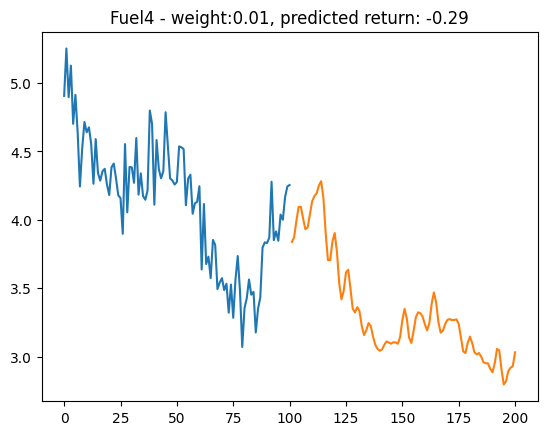

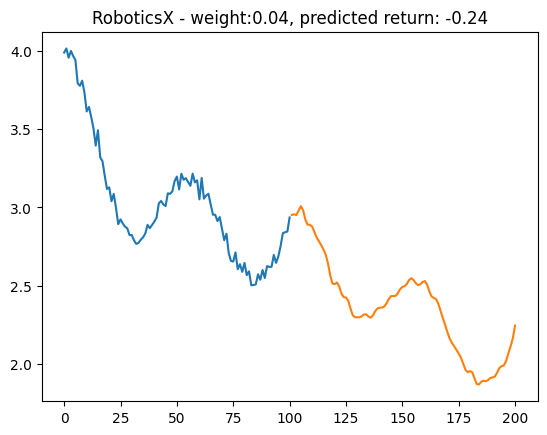

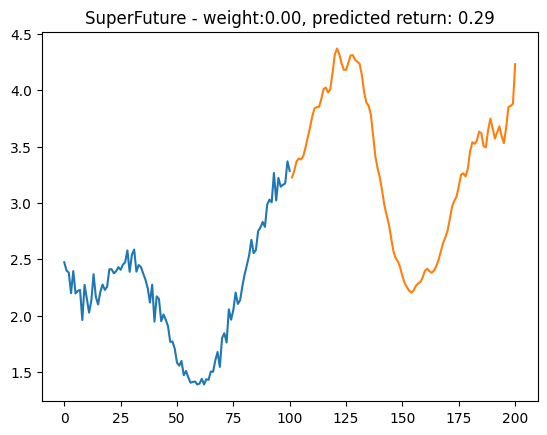

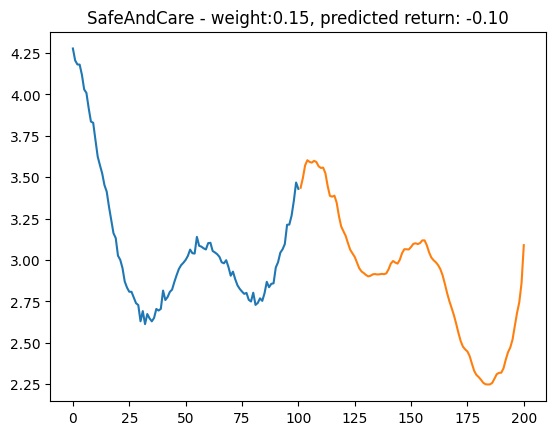

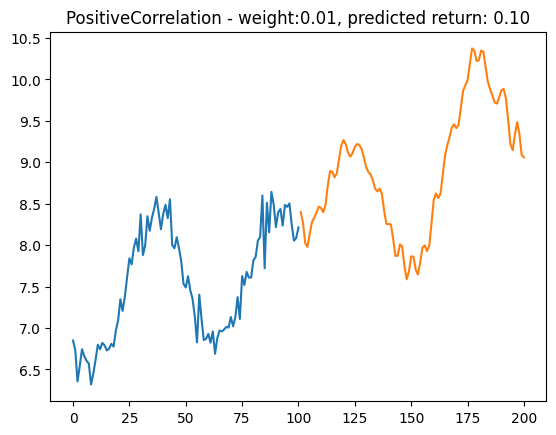

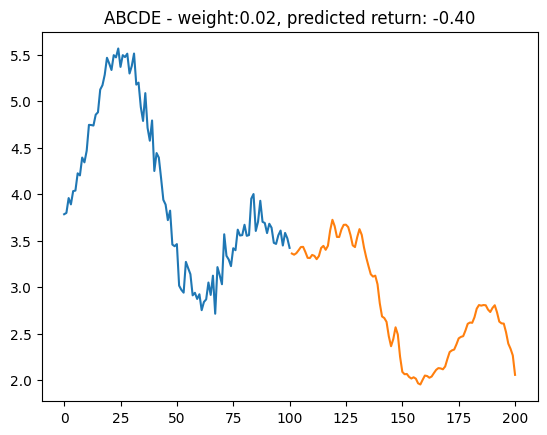

In [116]:
chosen_weights = None
min_return = 0.1
for i, ret in enumerate(ecm_x_returns):
    if ret >= min_return:
        chosen_weights = ecm_solutions[i]
        break

print(f"Expected return: {ecm_x_returns[i]:.2f}, expected risk: {ecm_x_returns[i]:2f}")
for i, key in enumerate(stocks):
    stock_datapoints = stocks[key]
    x = np.arange(len(stock_datapoints))
    plt.title(f"{key} - weight:{chosen_weights[i]:.2f}, predicted return: {stocks_predicted_ratios[key] - 1:.2f}")
    plt.plot(x, stock_datapoints)
    predictions, err = harmonic_regression_prediction(stock_datapoints, harmonic_order, period_len)
    px = np.arange(len(stock_datapoints), len(stock_datapoints) + 100)
    plt.plot(px, predictions)
    plt.show()

